### Tasks

* 1. Given a small dataset of 2D points representing food delivery locations (e.g., [2,3], [5,8], [1,2], [6,9], [7,7]), plot the points on graph paper or using matplotlib, randomly pick two initial centroids, and manually assign each point to the nearest centroid using Euclidean distance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
points = np.array([[2, 3], [5, 8], [1, 2], [6, 9], [7, 7]])
centroids = np.array([[2, 3], [7, 7]])

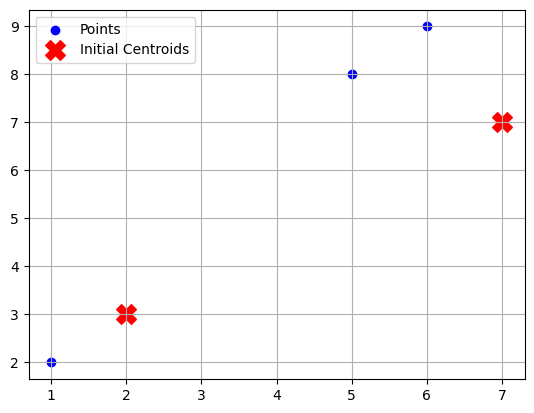

In [3]:
plt.scatter(points[:, 0], points[:, 1], color="blue", label="Points")
plt.scatter(centroids[:, 0], centroids[:, 1], color="red", marker="X", s=200, label="Initial Centroids")
plt.grid()
plt.legend()
plt.show()

* 2. Write a Python function assign_clusters(points, centroids) that takes a list of points and a list of centroids, and returns a list showing which cluster each point belongs to using Euclidean distance.

In [4]:
def assign_clusters(points, centroids):
    assignments = []
    for p in points:
        distances = [np.sqrt(np.sum((p - c)**2)) for c in centroids]
        assignments.append(int(np.argmin(distances)))

    return assignments

# points = np.array([[2, 3], [5, 8], [1, 2], [6, 9], [7, 7]])
# centroids = np.array([[2, 3], [7, 7]])

print(assign_clusters(points, centroids))

[0, 1, 0, 1, 1]


* 3. Update your assign_clusters code to work with Manhattan distance as well. Allow the user to choose between 'euclidean' and 'manhattan' as a parameter.

In [5]:
def assign_clusters_updated(points, centroids, metric):
    assignments = []
    for p in points:
        if metric == "euclidean":
            distances = [np.sqrt(np.sum((p - c)**2)) for c in centroids]
        elif metric == "manhattan":
            distances = [np.sum(np.abs(p - c)) for c in centroids]
            
    
        assignments.append(int(np.argmin(distances)))
        
    return assignments


print("Euclidean:", assign_clusters_updated(points, centroids, metric="euclidean"))
print("Manhattan:", assign_clusters_updated(points, centroids, metric="manhattan"))

Euclidean: [0, 1, 0, 1, 1]
Manhattan: [0, 1, 0, 1, 1]


* 4. Implement a function update_centroids(points, assignments, k) that calculates the new centroid for each cluster as the mean of the assigned points. Test it with a sample dataset of your choice.

In [6]:
def update_centroids(points, assignments, k):
    new_centroids = []
    for i in range(k):
        cluster_points = [points[j] for j in range(len(points)) if assignments[j] == i]
        if len(cluster_points) > 0:
            new_centroids.append(np.mean(cluster_points, axis=0))
        else:
            new_centroids.append(points[np.random.choice(len(points))])

    return np.array(new_centroids)

assignments_test = assign_clusters(points, centroids)

new_cents = update_centroids(points, assignments_test, 2)
print("Updated Centroids:\n", new_cents)

Updated Centroids:
 [[1.5 2.5]
 [6.  8. ]]


* 5. Use the Elbow Method to determine the optimal number of clusters (k) for a dataset of your choice (e.g., favorite songs by tempo and danceability, or Zomato restaurant ratings and price). Plot the within-cluster sum of squares for k=1 to k=6 and identify the 'elbow' point.<br><br><em><strong>Hint:</strong> Use sklearn's KMeans and matplotlib for plotting.</em>

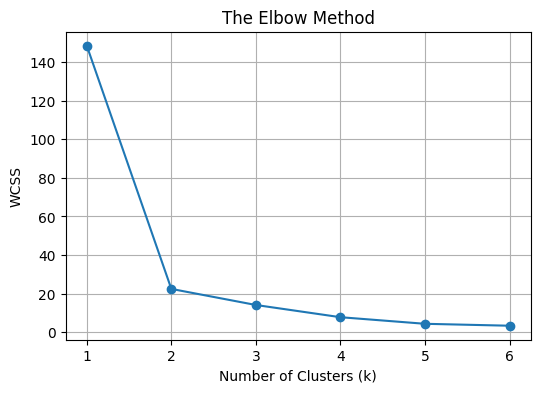

In [7]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

data = [ [2,3], [5,8], [1,2], [6,9], [7,7], [8,6], [3,4], [2,2], [9,8], [8,9]]

wcss = []

for k in range(1,7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
)

    kmeans.fit(data)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,7), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("The Elbow Method")
plt.grid(True)
plt.show()